# Application 2 — House Price Prediction

## 1. Problem Definition

The objective of this application is to predict the historical sale price of a London property from information available about the property and its location.

This is a supervised regression problem.

Let $X$ denote the property features and $y$ denote the historical sale price.

For one property:

$$
x_i =
[x_{i1}, x_{i2}, \ldots, x_{id}]^T
\in \mathbb{R}^{d}
$$

For the complete dataset:

$$
X \in \mathbb{R}^{N \times d}
$$

where $N$ is the number of property records and $d$ is the number of input dimensions after feature selection but before categorical expansion.

The learning objective is to estimate a function

$$
f(X) \rightarrow y
$$

that can predict the price of an unseen property.

The assignment also requires the representation of the data to be explained before model training. Therefore, the notebook will trace the transformation from the original tabular record to the numerical feature representation supplied to the regression models.

In [1]:
# ============================================================
# 1.Import libraries and configure the experiment
# ============================================================

import os
import sys
import time
import json
import random
import platform
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display

warnings.filterwarnings("ignore")

RANDOM_SEED = 42

np.random.seed(RANDOM_SEED)
random.seed(RANDOM_SEED)

print("Python version :", sys.version.split()[0])
print("Pandas version :", pd.__version__)
print("NumPy version  :", np.__version__)
print("OS             :", platform.system())
print("Random seed    :", RANDOM_SEED)

Python version : 3.14.6
Pandas version : 3.0.3
NumPy version  : 2.4.6
OS             : Windows
Random seed    : 42


## 2. Dataset Source

The selected dataset is London House Price Data from Kaggle.

Source:

https://www.kaggle.com/datasets/jakewright/house-price-data

The dataset contains historical London property transactions together with property characteristics, geographical variables, energy-related information, and price-related fields.


### Question

Why is this dataset suitable for the house-price application?

### Answer

The dataset directly represents London property transactions and provides both numerical and categorical property characteristics. It therefore supports the required transformation from raw tabular data into a numerical feature representation for regression.

In [2]:
# ============================================================
# 2. Dataset Source and Experiment Configuration
# ============================================================

import os
import sys
import time
import json
import random
import platform
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display


# ------------------------------------------------------------
# Warning configuration
# ------------------------------------------------------------

warnings.filterwarnings(
    "ignore"
)


# ------------------------------------------------------------
# Reproducibility
# ------------------------------------------------------------

RANDOM_SEED = 42

np.random.seed(
    RANDOM_SEED
)

random.seed(
    RANDOM_SEED
)


# ------------------------------------------------------------
# Dataset configuration
# ------------------------------------------------------------

TARGET = "history_price"


DATA_PATH = (
    "../../DATA/"
    "kaggle_london_house_price_data.csv"
)


# ------------------------------------------------------------
# Environment information
# ------------------------------------------------------------

print(
    "Dataset           : London House Price Data"
)

print(
    "Kaggle URL        : "
    "https://www.kaggle.com/datasets/jakewright/house-price-data"
)

print(
    "Target            :",
    TARGET
)

print(
    "Random seed       :",
    RANDOM_SEED
)

print(
    "Python version    :",
    sys.version.split()[0]
)

print(
    "Pandas version    :",
    pd.__version__
)

print(
    "NumPy version     :",
    np.__version__
)

print(
    "Operating system  :",
    platform.system()
)

Dataset           : London House Price Data
Kaggle URL        : https://www.kaggle.com/datasets/jakewright/house-price-data
Target            : history_price
Random seed       : 42
Python version    : 3.14.6
Pandas version    : 3.0.3
NumPy version     : 2.4.6
Operating system  : Windows


## 3. Dataset Loading

The CSV file is loaded into a Pandas DataFrame.

If the original dataset contains more than 100,000 rows, a deterministic sample is created using the fixed random seed. This provides a reproducible experimental dataset while keeping model training practical.

### Question

How is the raw CSV converted into a form that can be inspected and processed?

### Answer

The CSV file is converted into a Pandas DataFrame. At this stage, the original columns and values are preserved so that data quality and representation can be examined before any modelling transformation is applied.

In [3]:
# ============================================================
# 3. Dataset Loading
# ============================================================

from pathlib import Path


# ------------------------------------------------------------
# Resolve dataset path
# ------------------------------------------------------------

DATA_PATH = Path(
    "../../DATA/"
    "kaggle_london_house_price_data.csv"
)


print(
    "Dataset path:"
)

print(
    DATA_PATH.resolve()
)


# ------------------------------------------------------------
# Verify dataset file
# ------------------------------------------------------------

if not DATA_PATH.exists():

    raise FileNotFoundError(

        "Dataset file was not found.\n\n"
        f"Expected path:\n"
        f"{DATA_PATH.resolve()}"

    )


# ------------------------------------------------------------
# Load the complete dataset
# ------------------------------------------------------------

df = pd.read_csv(
    DATA_PATH
)


# ------------------------------------------------------------
# Verify target
# ------------------------------------------------------------

if TARGET not in df.columns:

    raise ValueError(

        f"Target column '{TARGET}' "
        "was not found in the dataset.\n\n"

        "Available columns:\n"

        +
        "\n".join(
            f"- {column}"
            for column in df.columns
        )

    )


# ------------------------------------------------------------
# Dataset information
# ------------------------------------------------------------

print(
    "\nDataset loaded successfully."
)

print(
    "Number of observations:",
    len(df)
)

print(
    "Number of columns:",
    df.shape[1]
)

print(
    "Dataset shape:",
    df.shape
)

Dataset path:
C:\Users\ADMIN\Downloads\Intelligent System\assignment 2\DATA\kaggle_london_house_price_data.csv

Dataset loaded successfully.
Number of observations: 418201
Number of columns: 28
Dataset shape: (418201, 28)


## 4. Dataset Inspection

The first inspection establishes the structure of the raw dataset through its dimensions, sample records, data types, and descriptive statistics.

### Questions

1. What does one row represent?
2. What does one column represent?
3. What are the main data types?
4. Which variables may be useful for predicting price?

### Answer

Each row represents one historical property transaction. Each column describes one attribute of that transaction or property.

The dataset contains both numerical and categorical information, so a single preprocessing strategy cannot be applied to every feature.

In [4]:
# ============================================================
# 4. Dataset Inspection
# ============================================================

print("Dataset shape:")
print(df.shape)


print("\nFirst five observations:")
display(
    df.head()
)


print("\nColumn data types:")
display(
    df.dtypes
    .to_frame("dtype")
)


print("\nDescriptive statistics:")
display(
    df.describe(
        include="all"
    ).T
)

Dataset shape:
(418201, 28)

First five observations:


,fullAddress,postcode,country,outcode,latitude,longitude,bathrooms,bedrooms,floorAreaSqM,livingRooms,...,saleEstimate_upperPrice,saleEstimate_confidenceLevel,saleEstimate_ingestedAt,saleEstimate_valueChange.numericChange,saleEstimate_valueChange.percentageChange,saleEstimate_valueChange.saleDate,history_date,history_price,history_percentageChange,history_numericChange
0,"Flat 9, 35 Furnival Street, London, EC4A 1JQ",EC4A 1JQ,England,EC4A,51.517282,-0.110314,1.0,1.0,45.0,1.0,...,630000.0,HIGH,2024-10-07T13:26:59.894Z,244000.0,68.539326,2010-03-30,1995-01-02,830000,NaN,NaN
1,"Flat 6, 35 Furnival Street, London, EC4A 1JQ",EC4A 1JQ,England,EC4A,51.517282,-0.110314,NaN,NaN,NaN,NaN,...,660000.0,MEDIUM,2024-10-07T13:26:59.894Z,425000.0,242.857143,2000-05-26,1995-01-02,830000,NaN,NaN
2,"Flat 35, Octavia House, Medway Street, London,...",SW1P 2TA,England,SW1P,51.495505,-0.132379,2.0,2.0,71.0,1.0,...,834000.0,MEDIUM,2025-01-10T11:04:57.114Z,49000.0,6.901408,2019-09-04,1995-01-03,249950,NaN,NaN
3,"24 Chester Court, Lomond Grove, London, SE5 7HS",SE5 7HS,England,SE5,51.478185,-0.092201,1.0,1.0,64.0,1.0,...,407000.0,HIGH,2024-10-07T13:26:59.894Z,28000.0,7.777778,2024-01-25,1995-01-03,32000,NaN,NaN
4,"18 Alexandra Gardens, London, N10 3RL",N10 3RL,England,N10,51.588774,-0.139599,1.0,4.0,137.0,2.0,...,1324000.0,HIGH,2024-10-07T13:26:59.894Z,81000.0,6.864407,2022-12-14,1995-01-03,133000,NaN,NaN



Column data types:


,dtype
fullAddress,str
postcode,str
country,str
outcode,str
latitude,float64
longitude,float64
bathrooms,float64
bedrooms,float64
floorAreaSqM,float64
livingRooms,float64



Descriptive statistics:


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
fullAddress,418201,137760,"74 Western Beach Apartments, 36 Hanover Avenue...",224,NaN,NaN,NaN,NaN,NaN,NaN,NaN
postcode,418201,48392,SW1P 3AN,366,NaN,NaN,NaN,NaN,NaN,NaN,NaN
country,418201,1,England,418201,NaN,NaN,NaN,NaN,NaN,NaN,NaN
outcode,418201,168,SE18,8307,NaN,NaN,NaN,NaN,NaN,NaN,NaN
latitude,418201.0,NaN,NaN,NaN,51.507522,0.056171,51.385708,51.464315,51.501581,51.548515,51.665823
longitude,418201.0,NaN,NaN,NaN,-0.101426,0.08693,-0.347055,-0.155996,-0.108482,-0.043582,0.139249
bathrooms,340270.0,NaN,NaN,NaN,1.444265,0.724478,1.0,1.0,1.0,2.0,9.0
bedrooms,377665.0,NaN,NaN,NaN,2.474884,1.160506,1.0,2.0,2.0,3.0,9.0
floorAreaSqM,392991.0,NaN,NaN,NaN,98.926543,55.938911,10.0,63.0,84.0,116.0,500.0
livingRooms,357701.0,NaN,NaN,NaN,1.282275,0.574412,1.0,1.0,1.0,1.0,9.0


## 5. Data-Quality Analysis

Data quality is examined before model development.

The analysis focuses on:

- missing values;
- duplicated records;
- invalid values;
- statistical outliers;
- target distribution.

### Question

Are there data-quality problems that could make the regression results unreliable?

### Answer

The notebook identifies problems first and applies cleaning only where there is a clear reason to do so. This prevents unnecessary modification of the original observations.

In [5]:
# ============================================================
# 5. Overall data-quality summary
# ============================================================

quality_summary = pd.DataFrame({

    "Rows":
        [len(df)],

    "Columns":
        [df.shape[1]],

    "Missing Values":
        [int(df.isna().sum().sum())],

    "Duplicate Rows":
        [int(df.duplicated().sum())]

})

display(
    quality_summary
)

,Rows,Columns,Missing Values,Duplicate Rows
0,418201,28,672132,7


## 6. Missing-Value Analysis

Missing values are analysed at the feature level.

### Question

Which features contain missing information, and should those observations be removed?

### Answer

Removing every row with a missing value can unnecessarily reduce the available training data.

For this reason, missing values will be handled inside the preprocessing pipeline:

- numerical features will use median imputation;
- categorical features will use most-frequent imputation.

The imputation parameters will be learned only from the training data.

In [6]:
# ============================================================
# 6. Missing-value analysis
# ============================================================

missing_summary = (
    df.isna()
    .sum()
    .to_frame(
        "Missing Count"
    )
)

missing_summary["Percentage"] = (
    missing_summary["Missing Count"]
    / len(df)
    * 100
)

missing_summary = (
    missing_summary
    .query(
        "`Missing Count` > 0"
    )
    .sort_values(
        "Missing Count",
        ascending=False
    )
)

if missing_summary.empty:

    print(
        "No missing values were found."
    )

else:

    display(
        missing_summary
    )

,Missing Count,Percentage
history_percentageChange,180219,43.093871
history_numericChange,180219,43.093871
currentEnergyRating,84526,20.211812
bathrooms,77931,18.634819
livingRooms,60500,14.466728
bedrooms,40536,9.692947
floorAreaSqM,25210,6.028202
tenure,11512,2.752743
rentEstimate_upperPrice,1741,0.416307
rentEstimate_currentPrice,1741,0.416307


## 7. Duplicate Analysis

Exact duplicate rows are checked before splitting the data.

### Question

Are there repeated records that could give some properties excessive influence during training?

### Answer

Exact duplicates should normally be removed because the same observation should not appear multiple times in the learning data.

The duplicate count is measured first, and only exact duplicates are removed.

In [7]:
# ============================================================
# 7. Duplicate analysis and removal
# ============================================================

duplicate_count = (
    df.duplicated()
    .sum()
)

print(
    "Duplicate rows:",
    duplicate_count
)


rows_before = len(df)


df = (
    df
    .drop_duplicates()
    .reset_index(
        drop=True
    )
)


print(
    "Rows removed:",
    rows_before - len(df)
)

print(
    "Rows after duplicate removal:",
    len(df)
)

Duplicate rows: 7
Rows removed: 7
Rows after duplicate removal: 418194


## 8. Invalid-Value Analysis

Invalid values are different from statistical outliers.

An outlier may represent a real expensive or unusual property, while an invalid value violates a basic domain constraint.

### Questions

Which observations are clearly invalid?

How should these observations be handled?

### Answer

Examples of invalid values include non-positive property prices, non-positive floor area, and negative room counts.

These observations cannot represent valid house-price training examples and are therefore removed when the corresponding feature is available.

In [8]:
# ============================================================
# 8. Invalid-value analysis
# ============================================================

invalid_checks = {}


if TARGET in df.columns:

    invalid_checks[TARGET] = (
        df[TARGET].notna()
        &
        (df[TARGET] <= 0)
    )


for column in [
    "floorAreaSqM",
    "bedrooms",
    "bathrooms",
    "livingRooms"
]:

    if column in df.columns:

        invalid_checks[column] = (
            df[column].notna()
            &
            (df[column] < 0)
        )


invalid_results = []

for column, mask in invalid_checks.items():

    invalid_results.append({

        "Feature":
            column,

        "Invalid Count":
            int(mask.sum()),

        "Percentage":
            round(
                mask.mean() * 100,
                3
            )

    })


invalid_df = pd.DataFrame(
    invalid_results
)

display(
    invalid_df
)

,Feature,Invalid Count,Percentage
0,history_price,0,0.0
1,floorAreaSqM,0,0.0
2,bedrooms,0,0.0
3,bathrooms,0,0.0
4,livingRooms,0,0.0


In [9]:
# ============================================================
# Remove clearly invalid observations
# ============================================================

before_cleaning = len(df)


df = df[
    df[TARGET].notna()
    &
    (df[TARGET] > 0)
]


if "floorAreaSqM" in df.columns:

    df = df[
        df["floorAreaSqM"].isna()
        |
        (df["floorAreaSqM"] > 0)
    ]


for column in [
    "bedrooms",
    "bathrooms",
    "livingRooms"
]:

    if column in df.columns:

        df = df[
            df[column].isna()
            |
            (df[column] >= 0)
        ]


df = df.reset_index(
    drop=True
)


print(
    "Rows before invalid-value cleaning:",
    before_cleaning
)

print(
    "Rows after cleaning:",
    len(df)
)

print(
    "Rows removed:",
    before_cleaning - len(df)
)

Rows before invalid-value cleaning: 418194
Rows after cleaning: 418194
Rows removed: 0


## 9. Outlier Analysis

### Question

Which numerical variables contain unusually extreme observations?

The Interquartile Range method is used to identify statistical outliers.

$$
IQR = Q_3-Q_1
$$

The lower and upper bounds are:

$$
L=Q_1-1.5(IQR)
$$

$$
U=Q_3+1.5(IQR)
$$

An observation outside these limits is flagged as an outlier.

### Answer

Outlier detection is used to understand the data rather than automatically delete all extreme observations. In real-estate data, an unusually expensive or large property can be a legitimate observation.

In [10]:
# ============================================================
# 9. IQR-based outlier analysis
# ============================================================

outlier_features = [

    column

    for column in [

        TARGET,
        "floorAreaSqM",
        "bedrooms",
        "bathrooms",
        "livingRooms"

    ]

    if column in df.columns

]


outlier_results = []


for column in outlier_features:

    values = (
        df[column]
        .dropna()
    )


    if values.empty:

        continue


    q1 = values.quantile(
        0.25
    )

    q3 = values.quantile(
        0.75
    )

    iqr = (
        q3 - q1
    )

    lower = (
        q1 - 1.5 * iqr
    )

    upper = (
        q3 + 1.5 * iqr
    )

    mask = (
        (values < lower)
        |
        (values > upper)
    )


    outlier_results.append({

        "Feature":
            column,

        "Outlier Count":
            int(mask.sum()),

        "Percentage":
            round(
                mask.mean() * 100,
                2
            )

    })


outlier_df = pd.DataFrame(
    outlier_results
)

display(
    outlier_df
)

,Feature,Outlier Count,Percentage
0,history_price,34699,8.30
1,floorAreaSqM,23355,5.94
2,bedrooms,22333,5.91
3,bathrooms,6085,1.79
4,livingRooms,82907,23.18


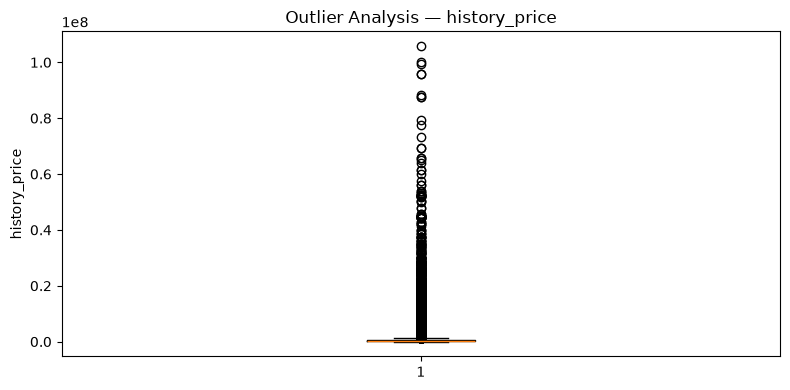

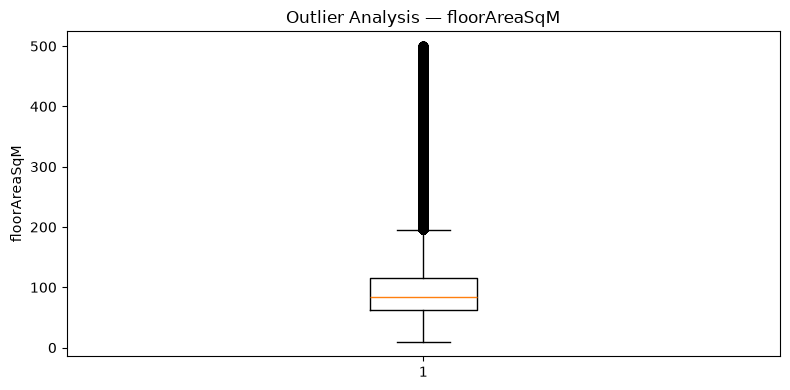

In [11]:
# ============================================================
# Representative outlier visualization
# ============================================================

for column in [
    TARGET,
    "floorAreaSqM"
]:

    if column not in df.columns:

        continue


    plt.figure(
        figsize=(8, 4)
    )


    plt.boxplot(
        df[column].dropna()
    )


    plt.title(
        f"Outlier Analysis — {column}"
    )

    plt.ylabel(
        column
    )

    plt.tight_layout()

    plt.show()

## 10. Exploratory Data Analysis

EDA is used to understand the statistical structure of the dataset before model development.

The analysis focuses on:

1. target distribution;
2. important numerical feature distributions;
3. relationships between features and price;
4. categorical effects on price;
5. numerical correlations.

### Question

Which characteristics appear to contain useful information about historical house price?

### Answer

The objective is not to prove causality. Instead, EDA identifies observable patterns that can motivate the choice of model family and preprocessing strategy.

### Target Distribution

### Question

Is historical house price evenly distributed?

A strongly skewed target can make large prediction errors disproportionately important, which affects the interpretation of regression metrics.

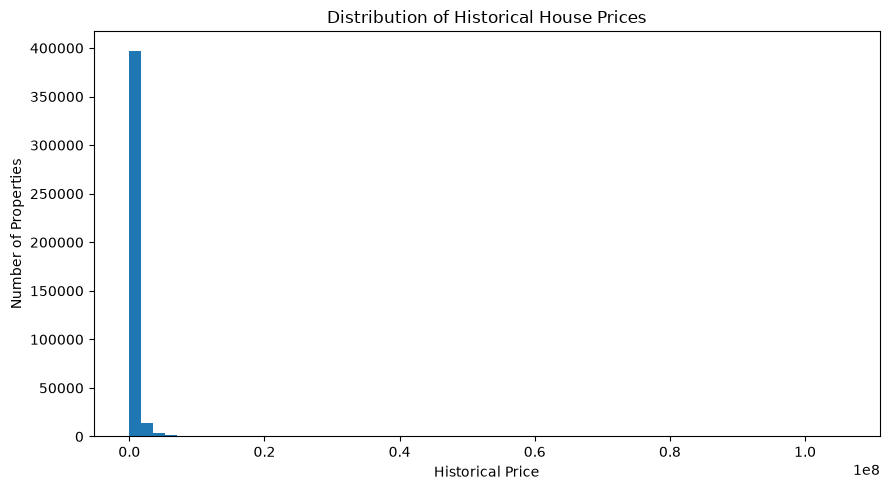

,history_price
count,4.181940e+05
mean,6.395867e+05
std,1.327944e+06
min,1.000000e+04
25%,2.280000e+05
50%,4.000000e+05
75%,6.650000e+05
max,1.058000e+08


In [12]:
# ============================================================
# Target distribution
# ============================================================

plt.figure(
    figsize=(9, 5)
)

plt.hist(
    df[TARGET].dropna(),
    bins=60
)

plt.title(
    "Distribution of Historical House Prices"
)

plt.xlabel(
    "Historical Price"
)

plt.ylabel(
    "Number of Properties"
)

plt.tight_layout()

plt.show()


display(
    df[TARGET]
    .describe()
    .to_frame(
        "history_price"
    )
)

### Interpretation

The distribution should be examined for a long upper tail.

If the target is strongly right-skewed, a relatively small number of expensive properties may produce very large prediction errors.

This motivates evaluating the models with both MAE and RMSE.

### Property Size and Price

### Question

How does floor area relate to historical house price?

Floor area is a direct physical characteristic of the property and is therefore an important variable for examining the relationship between property characteristics and price.

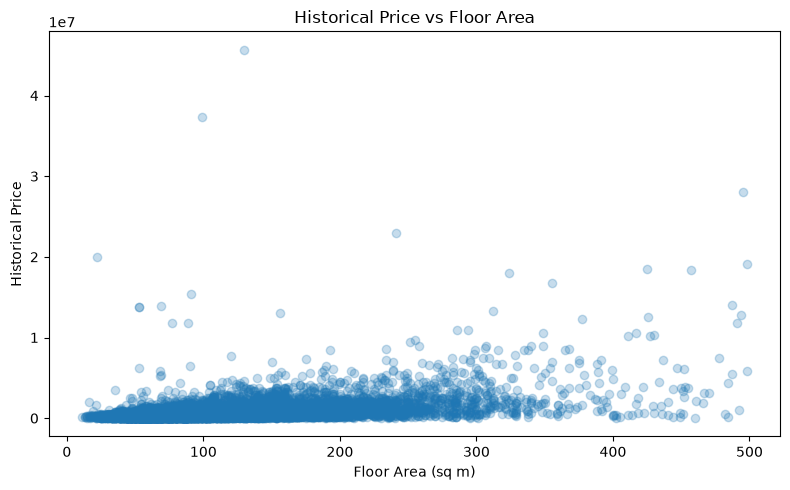

In [13]:
# ============================================================
# Floor area versus price
# ============================================================

if "floorAreaSqM" in df.columns:

    area_price = (
        df[
            [
                "floorAreaSqM",
                TARGET
            ]
        ]
        .dropna()
    )


    area_price = (
        area_price
        .sample(
            min(
                20000,
                len(area_price)
            ),
            random_state=RANDOM_SEED
        )
    )


    plt.figure(
        figsize=(8, 5)
    )


    plt.scatter(

        area_price["floorAreaSqM"],

        area_price[TARGET],

        alpha=0.25

    )


    plt.title(
        "Historical Price vs Floor Area"
    )

    plt.xlabel(
        "Floor Area (sq m)"
    )

    plt.ylabel(
        "Historical Price"
    )

    plt.tight_layout()

    plt.show()

### Interpretation

A positive relationship between floor area and price would indicate that larger properties generally tend to have higher transaction prices.

The relationship is unlikely to be perfectly linear because property location, type, tenure, and other characteristics also contribute to price variation.

### Property Type and Price

### Question

Do different property types have different typical price levels?

Property type is categorical information. Comparing its median price provides an initial indication of whether this information could be useful for prediction.

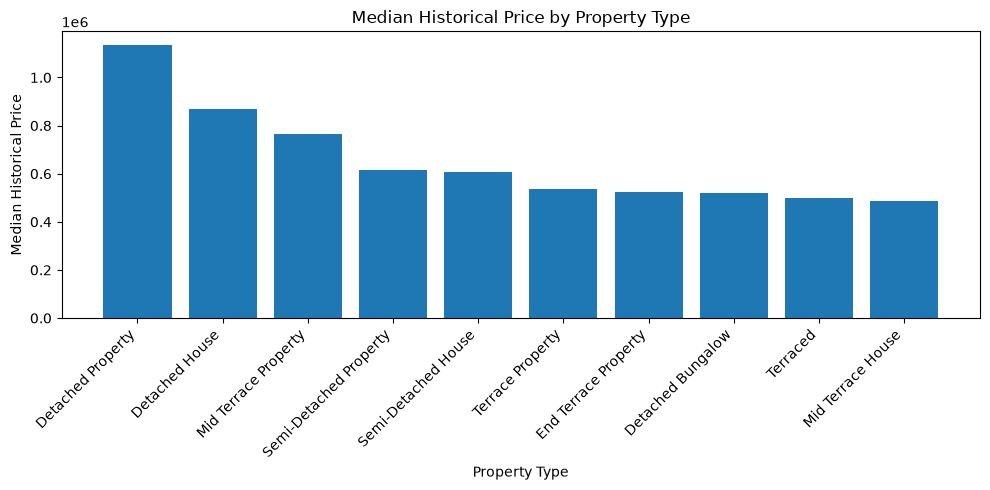

In [14]:
# ============================================================
# Median price by property type
# ============================================================

if "propertyType" in df.columns:

    property_type_summary = (

        df[
            [
                "propertyType",
                TARGET
            ]
        ]

        .dropna()

        .groupby(
            "propertyType"
        )[TARGET]

        .median()

        .sort_values(
            ascending=False
        )

        .head(10)

    )


    plt.figure(
        figsize=(10, 5)
    )


    plt.bar(
        property_type_summary.index,
        property_type_summary.values
    )


    plt.xticks(
        rotation=45,
        ha="right"
    )


    plt.title(
        "Median Historical Price by Property Type"
    )

    plt.xlabel(
        "Property Type"
    )

    plt.ylabel(
        "Median Historical Price"
    )


    plt.tight_layout()

    plt.show()

### Interpretation

If median prices differ substantially between property types, categorical information contributes predictive information beyond numerical measurements.

This motivates encoding categorical variables rather than discarding them.

### Numerical Correlation

### Question

How are the major numerical variables related to one another and to historical price?

Correlation is useful for identifying strong linear relationships and potentially redundant variables. It does not establish causality.

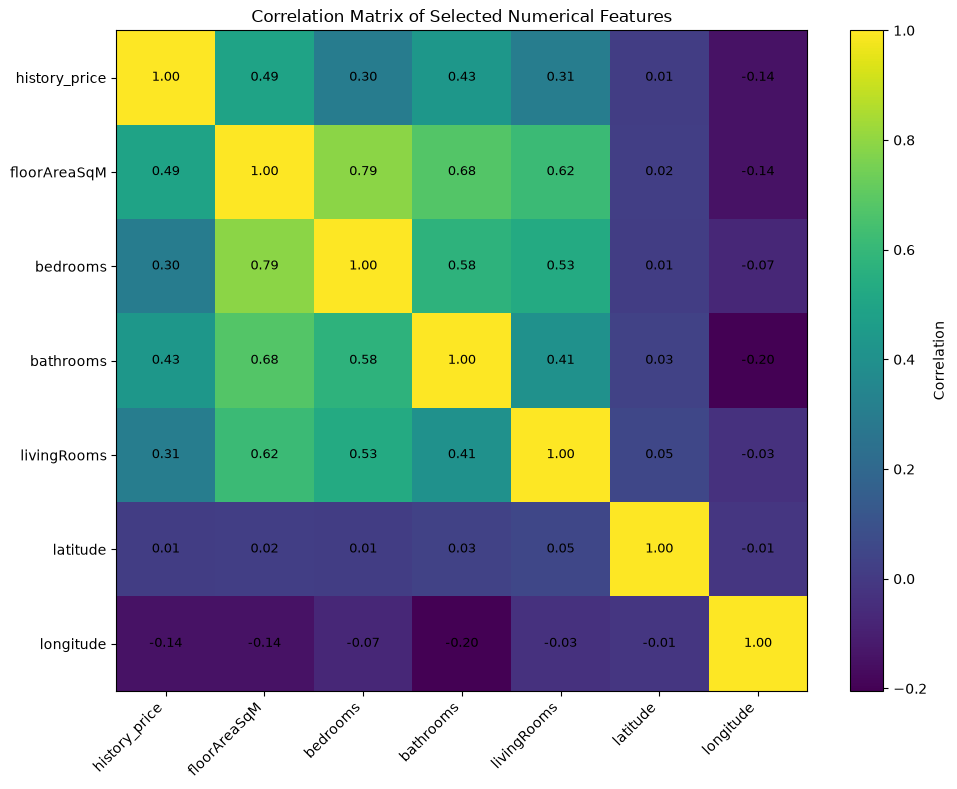

In [44]:
# ============================================================
# Correlation matrix with numerical values
# ============================================================

correlation_candidates = [
    TARGET,
    "floorAreaSqM",
    "bedrooms",
    "bathrooms",
    "livingRooms",
    "latitude",
    "longitude"
]


correlation_columns = [
    column
    for column in correlation_candidates
    if column in df.columns
]


corr = (
    df[correlation_columns]
    .corr()
)


plt.figure(
    figsize=(10, 8)
)


image = plt.imshow(
    corr,
    aspect="auto"
)


# ------------------------------------------------------------
# Axis labels
# ------------------------------------------------------------

plt.xticks(
    range(len(corr.columns)),
    corr.columns,
    rotation=45,
    ha="right"
)

plt.yticks(
    range(len(corr.columns)),
    corr.columns
)


# ------------------------------------------------------------
# Display correlation values inside each cell
# ------------------------------------------------------------

for row in range(
    corr.shape[0]
):

    for col in range(
        corr.shape[1]
    ):

        value = corr.iloc[
            row,
            col
        ]

        plt.text(
            col,
            row,
            f"{value:.2f}",
            ha="center",
            va="center",
            fontsize=9
        )


# ------------------------------------------------------------
# Color scale
# ------------------------------------------------------------

plt.colorbar(
    image,
    label="Correlation"
)


plt.title(
    "Correlation Matrix of Selected Numerical Features"
)

plt.tight_layout()

plt.show()

## 11. Feature Types

### Question

Which features are numerical, which are categorical, and which should not be directly used as predictors?

Numerical features represent measurable quantities.

Categorical features represent discrete property characteristics and require encoding before model training.

Some columns are excluded because they are:

- the target;
- raw address identifiers;
- current price estimates;
- fields that could expose information unavailable at the historical transaction time.

### Answer

The final feature set must contain variables that are available and meaningful for predicting the historical price. Excluding leakage-prone fields is therefore part of the feature-definition process, not merely a modelling choice.

In [16]:
# ============================================================
# 11. Define predictive features
# ============================================================

excluded_columns = {
    TARGET
}


# ------------------------------------------------------------
# Raw high-cardinality address fields
# ------------------------------------------------------------

for column in [
    "fullAddress",
    "postcode"
]:

    if column in df.columns:

        excluded_columns.add(
            column
        )


# ------------------------------------------------------------
# Current market estimates
#
# These describe current estimates and may contain future
# information relative to a historical transaction.
# ------------------------------------------------------------

for column in df.columns:

    lower_name = column.lower()


    if (
        "saleestimate" in lower_name
        or
        "rentestimate" in lower_name
    ):

        excluded_columns.add(
            column
        )


# ------------------------------------------------------------
# Predictive matrix
# ------------------------------------------------------------

candidate_features = [

    column

    for column in df.columns

    if column not in excluded_columns

]


X_raw = (
    df[
        candidate_features
    ]
    .copy()
)


y = (
    df[TARGET]
    .copy()
)


numeric_features = (

    X_raw
    .select_dtypes(
        include=np.number
    )
    .columns
    .tolist()

)


categorical_features = (

    X_raw
    .select_dtypes(
        include=[
            "object",
            "category",
            "bool"
        ]
    )
    .columns
    .tolist()

)


print(
    "Numerical features:",
    len(numeric_features)
)

print(
    numeric_features
)

print(
    "\nCategorical features:",
    len(categorical_features)
)

print(
    categorical_features
)

print(
    "\nExcluded columns:"
)

print(
    sorted(
        excluded_columns
    )
)

Numerical features: 8
['latitude', 'longitude', 'bathrooms', 'bedrooms', 'floorAreaSqM', 'livingRooms', 'history_percentageChange', 'history_numericChange']

Categorical features: 6
['country', 'outcode', 'tenure', 'propertyType', 'currentEnergyRating', 'history_date']

Excluded columns:
['fullAddress', 'history_price', 'postcode', 'rentEstimate_currentPrice', 'rentEstimate_lowerPrice', 'rentEstimate_upperPrice', 'saleEstimate_confidenceLevel', 'saleEstimate_currentPrice', 'saleEstimate_ingestedAt', 'saleEstimate_lowerPrice', 'saleEstimate_upperPrice', 'saleEstimate_valueChange.numericChange', 'saleEstimate_valueChange.percentageChange', 'saleEstimate_valueChange.saleDate']


## 12. Data Representation

The assignment requires the transformation from raw data into a computational representation to be made explicit.

The representation changes through the following stages:

$$
\text{CSV}
\rightarrow
\text{DataFrame}
\rightarrow
\text{Selected Features}
\rightarrow
\text{Numerical Feature Matrix}
\rightarrow
\text{Model Input}
$$

For one property:

$$
x_i=
[x_{i1},x_{i2},\ldots,x_{id}]^T
\in\mathbb{R}^{d}
$$

For the complete dataset:

$$
X\in\mathbb{R}^{N\times d}
$$

### Questions

1. What does one row represent?
2. What does one feature dimension represent?
3. How are categorical features converted into numerical dimensions?
4. Why can the final model dimension be larger than the original dimension?

### Answer

One row represents one property transaction.

Each original dimension corresponds to one selected property characteristic.

Categorical features are expanded into binary dimensions through one-hot encoding. Therefore, one categorical column can become several model-input dimensions.

In [17]:
# ============================================================
# 12. Original data representation
# ============================================================

N = len(X_raw)

d_original = X_raw.shape[1]


print(
    "Number of observations:",
    N
)

print(
    "Original feature dimension:",
    d_original
)


print(
    f"\nX ∈ R^({N} × {d_original})"
)


print(
    "\nOne original property record:"
)

display(
    X_raw.iloc[
        [0]
    ]
)

Number of observations: 418194
Original feature dimension: 14

X ∈ R^(418194 × 14)

One original property record:


,country,outcode,latitude,longitude,bathrooms,bedrooms,floorAreaSqM,livingRooms,tenure,propertyType,currentEnergyRating,history_date,history_percentageChange,history_numericChange
0,England,EC4A,51.517282,-0.110314,1.0,1.0,45.0,1.0,Leasehold,Purpose Built Flat,NaN,1995-01-02,NaN,NaN


## 13. Feature Engineering

### Question

Can existing information be transformed into a representation that is more useful for regression without introducing future information?

Two transformations are considered.

First, a transaction date is decomposed into year and month when such a date is available.

Second, a logarithmic version of floor area is created to provide an additional representation for a potentially skewed numerical feature.

Current market estimates remain excluded because they may contain information from a later point in time than the historical transaction.

In [18]:
# ============================================================
# 13. Feature engineering
# ============================================================

X_engineered = X_raw.copy()


# ------------------------------------------------------------
# Transform date columns into year and month
# ------------------------------------------------------------

date_columns = [

    column

    for column in X_engineered.columns

    if "date" in column.lower()

]


new_date_features = []


for column in date_columns:

    parsed_date = pd.to_datetime(

        X_engineered[column],

        errors="coerce"

    )


    if parsed_date.notna().any():

        year_name = (
            f"{column}_year"
        )

        month_name = (
            f"{column}_month"
        )


        X_engineered[
            year_name
        ] = parsed_date.dt.year


        X_engineered[
            month_name
        ] = parsed_date.dt.month


        new_date_features.extend([

            year_name,
            month_name

        ])


        X_engineered = (
            X_engineered
            .drop(
                columns=[column]
            )
        )


# ------------------------------------------------------------
# Log-transform property area
# ------------------------------------------------------------

if "floorAreaSqM" in X_engineered.columns:

    X_engineered[
        "log_floorAreaSqM"
    ] = np.log1p(

        X_engineered[
            "floorAreaSqM"
        ].clip(
            lower=0
        )

    )


print(
    "Shape before engineering:",
    X_raw.shape
)

print(
    "Shape after engineering :",
    X_engineered.shape
)


new_features = [

    column

    for column in X_engineered.columns

    if column not in X_raw.columns

]


print(
    "\nCreated features:"
)

print(
    new_features
)

Shape before engineering: (418194, 14)
Shape after engineering : (418194, 16)

Created features:
['history_date_year', 'history_date_month', 'log_floorAreaSqM']


## 14. Train, Validation, and Test Split

### Question

How can model development be performed without allowing test observations to influence preprocessing or model selection?

The data are divided into:

$$
D=
D_{\text{train}}
\cup
D_{\text{validation}}
\cup
D_{\text{test}}
$$

using a 70/15/15 split.

The training set is used to learn model and preprocessing parameters.

The validation set is used for model comparison and hyperparameter experiments.

The test set remains isolated until final evaluation.

Stratification is not used because house price is a continuous regression target.

In [19]:
# ============================================================
# 14. 70 / 15 / 15 train-validation-test split
# ============================================================

from sklearn.model_selection import train_test_split


X_train, X_temp, y_train, y_temp = (

    train_test_split(

        X_engineered,
        y,

        test_size=0.30,

        random_state=RANDOM_SEED

    )

)


X_val, X_test, y_val, y_test = (

    train_test_split(

        X_temp,
        y_temp,

        test_size=0.50,

        random_state=RANDOM_SEED

    )

)


print(
    "Training set   :",
    X_train.shape,
    y_train.shape
)

print(
    "Validation set :",
    X_val.shape,
    y_val.shape
)

print(
    "Test set       :",
    X_test.shape,
    y_test.shape
)

Training set   : (292735, 16) (292735,)
Validation set : (62729, 16) (62729,)
Test set       : (62730, 16) (62730,)


## 15. Preprocessing Pipeline

Different feature types require different transformations.

### Numerical features

$$
\text{Median Imputation}
\rightarrow
\text{Standardization}
$$

### Categorical features

$$
\text{Most-Frequent Imputation}
\rightarrow
\text{One-Hot Encoding}
$$

### Question

How can preprocessing be applied consistently without causing data leakage?

### Answer

The preprocessing transformer is fitted only on the training set.

The learned transformation is then applied to validation, test, and future unseen data.

Therefore, validation and test observations do not influence the learned imputation values, scaling parameters, or category mapping.

In [20]:
# ============================================================
# 15. Build preprocessing pipeline
# ============================================================

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import (
    StandardScaler,
    OneHotEncoder
)


numeric_features = (

    X_train
    .select_dtypes(
        include=np.number
    )
    .columns
    .tolist()

)


categorical_features = (

    X_train
    .select_dtypes(
        include=[
            "object",
            "category",
            "bool"
        ]
    )
    .columns
    .tolist()

)


numeric_pipeline = Pipeline([

    (
        "imputer",
        SimpleImputer(
            strategy="median"
        )
    ),

    (
        "scaler",
        StandardScaler()
    )

])


categorical_pipeline = Pipeline([

    (
        "imputer",
        SimpleImputer(
            strategy="most_frequent"
        )
    ),

    (
        "onehot",
        OneHotEncoder(
            handle_unknown="ignore",
            min_frequency=20,
            sparse_output=False
        )
    )

])


preprocessor = ColumnTransformer(

    transformers=[

        (
            "numeric",
            numeric_pipeline,
            numeric_features
        ),

        (
            "categorical",
            categorical_pipeline,
            categorical_features
        )

    ],

    remainder="drop"

)


print(
    "Numerical feature count:",
    len(numeric_features)
)

print(
    "Categorical feature count:",
    len(categorical_features)
)

Numerical feature count: 11
Categorical feature count: 5


In [21]:
# ============================================================
# Fit preprocessing on training data only
# ============================================================

preprocessor.fit(
    X_train
)


X_train_processed = (
    preprocessor
    .transform(
        X_train
    )
)

X_val_processed = (
    preprocessor
    .transform(
        X_val
    )
)

X_test_processed = (
    preprocessor
    .transform(
        X_test
    )
)


feature_names = (
    preprocessor
    .get_feature_names_out()
)


d_final = len(
    feature_names
)


print(
    "Processed training shape   :",
    X_train_processed.shape
)

print(
    "Processed validation shape :",
    X_val_processed.shape
)

print(
    "Processed test shape       :",
    X_test_processed.shape
)

print(
    "\nOriginal feature dimension:",
    X_engineered.shape[1]
)

print(
    "Final model dimension     :",
    d_final
)


print(
    f"\nFinal model representation:"
)

print(
    f"X_train ∈ "
    f"R^({X_train_processed.shape[0]} × {d_final})"
)

Processed training shape   : (292735, 205)
Processed validation shape : (62729, 205)
Processed test shape       : (62730, 205)

Original feature dimension: 16
Final model dimension     : 205

Final model representation:
X_train ∈ R^(292735 × 205)


In [22]:
# ============================================================
# Final numerical representation preview
# ============================================================

processed_preview = pd.DataFrame(

    X_train_processed[:5],

    columns=feature_names

)

display(
    processed_preview
)

,numeric__latitude,numeric__longitude,numeric__bathrooms,numeric__bedrooms,numeric__floorAreaSqM,numeric__livingRooms,numeric__history_percentageChange,numeric__history_numericChange,numeric__history_date_year,numeric__history_date_month,...,categorical__propertyType_Terrace Property,categorical__propertyType_Terraced,categorical__propertyType_Terraced Bungalow,categorical__currentEnergyRating_A,categorical__currentEnergyRating_B,categorical__currentEnergyRating_C,categorical__currentEnergyRating_D,categorical__currentEnergyRating_E,categorical__currentEnergyRating_F,categorical__currentEnergyRating_G
0,-1.421310,-0.487019,-0.534874,-1.285827,-0.791011,-0.446993,-0.121580,-0.112060,0.950539,-0.785821,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
1,-0.674648,-1.742785,-0.534874,-0.385884,0.587372,-0.446993,-0.125688,0.243362,0.950539,-1.083351,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
2,1.231512,-0.398311,0.946285,-1.285827,-0.882903,-0.446993,0.635335,0.161961,1.057901,1.594421,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
3,-0.834313,0.801719,-0.534874,-0.385884,-0.791011,-0.446993,0.355459,0.339269,0.950539,0.404300,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
4,0.776212,-0.131862,-0.534874,-0.385884,-0.331550,-0.446993,-0.316493,-0.284532,1.057901,0.701830,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0


## 16. Baseline Model

### Question

How well can house price be predicted without learning relationships between property features and price?

A median baseline predicts the median training-set price for every validation property.

This baseline provides a reference point. The machine-learning models should achieve substantially lower error and a higher $R^2$ than this non-learning strategy.

In [23]:
# ============================================================
# 16. Median baseline
# ============================================================

from sklearn.dummy import DummyRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)


baseline_model = DummyRegressor(
    strategy="median"
)


start_time = time.perf_counter()


baseline_model.fit(

    X_train_processed,

    y_train

)


baseline_time = (

    time.perf_counter()
    -
    start_time

)


baseline_prediction = (

    baseline_model
    .predict(
        X_val_processed
    )

)


baseline_results = pd.DataFrame([{

    "Model":
        "Median Baseline",

    "MAE":
        mean_absolute_error(
            y_val,
            baseline_prediction
        ),

    "RMSE":
        np.sqrt(
            mean_squared_error(
                y_val,
                baseline_prediction
            )
        ),

    "R2":
        r2_score(
            y_val,
            baseline_prediction
        ),

    "Training Time (s)":
        round(
            baseline_time,
            4
        )

}])


display(
    baseline_results
)

,Model,MAE,RMSE,R2,Training Time (s)
0,Median Baseline,414395.709289,1.359839e+06,-0.031593,0.0044


## 17. Model Training

Five regression algorithms are compared.

1. Linear Regression
2. Ridge Regression
3. Decision Tree Regressor
4. Random Forest Regressor
5. Gradient Boosting Regressor

### Question

Why compare different model families instead of training only one algorithm?

### Answer

Different models represent different assumptions about the relationship between property features and price.

Linear Regression provides a simple linear baseline.

Ridge adds regularization to control coefficient magnitude.

Decision Tree models nonlinear decision rules.

Random Forest combines multiple trees.

Gradient Boosting builds an ensemble sequentially to improve prediction accuracy.

In [24]:
# ============================================================
# 17. Define the five regression models
# ============================================================

from sklearn.linear_model import (
    LinearRegression,
    Ridge
)

from sklearn.tree import (
    DecisionTreeRegressor
)

from sklearn.ensemble import (
    RandomForestRegressor,
    GradientBoostingRegressor
)


models = {

    "Linear Regression":
        LinearRegression(),

    "Ridge":
        Ridge(
            alpha=1.0
        ),

    "Decision Tree":
        DecisionTreeRegressor(
            max_depth=12,
            min_samples_leaf=5,
            random_state=RANDOM_SEED
        ),

    "Random Forest":
        RandomForestRegressor(
            n_estimators=200,
            max_depth=16,
            min_samples_leaf=2,
            n_jobs=-1,
            random_state=RANDOM_SEED
        ),

    "Gradient Boosting":
        GradientBoostingRegressor(
            n_estimators=200,
            learning_rate=0.05,
            max_depth=4,
            random_state=RANDOM_SEED
        )

}


print(
    "Models prepared:"
)

for model_name in models:

    print(
        "-",
        model_name
    )

Models prepared:
- Linear Regression
- Ridge
- Decision Tree
- Random Forest
- Gradient Boosting


In [25]:
# ============================================================
# Train the five models
# ============================================================

model_results = []

trained_models = {}

validation_predictions = {}


for model_name, model in models.items():

    print(
        f"Training {model_name}..."
    )


    start_time = (
        time.perf_counter()
    )


    model.fit(

        X_train_processed,

        y_train

    )


    training_time = (

        time.perf_counter()
        -
        start_time

    )


    prediction = (

        model
        .predict(
            X_val_processed
        )

    )


    model_results.append({

        "Model":
            model_name,

        "MAE":
            mean_absolute_error(
                y_val,
                prediction
            ),

        "RMSE":
            np.sqrt(
                mean_squared_error(
                    y_val,
                    prediction
                )
            ),

        "R2":
            r2_score(
                y_val,
                prediction
            ),

        "Training Time (s)":
            round(
                training_time,
                4
            )

    })


    trained_models[
        model_name
    ] = model


    validation_predictions[
        model_name
    ] = prediction


comparison_df = (

    pd.DataFrame(
        model_results
    )

    .sort_values(
        "RMSE"
    )

    .reset_index(
        drop=True
    )

)


display(
    comparison_df
)

Training Linear Regression...
Training Ridge...
Training Decision Tree...
Training Random Forest...
Training Gradient Boosting...


,Model,MAE,RMSE,R2,Training Time (s)
0,Random Forest,152731.198848,8.619428e+05,0.585533,485.7822
1,Gradient Boosting,184571.644547,8.876463e+05,0.560445,749.3185
2,Decision Tree,197778.677719,9.531536e+05,0.493174,8.5116
3,Linear Regression,294794.548124,1.078648e+06,0.350928,2.0141
4,Ridge,294747.888309,1.078660e+06,0.350914,0.4980


## 18. Model Comparison

### Question

Which regression model provides the most reliable prediction of house price?

The models are compared using five complementary metrics:

- Mean Absolute Error
- Mean Squared Error
- Root Mean Squared Error
- $R^2$
- Mean Absolute Percentage Error

Each metric captures a different aspect of regression performance.

MAE measures the average absolute prediction error.

MSE gives greater penalty to large errors.

RMSE is expressed in the same unit as house price and is particularly sensitive to large prediction errors.

$R^2$ measures how much of the variation in house price is explained by the model.

MAPE measures the average prediction error relative to the actual price.

Lower MAE, MSE, RMSE, and MAPE are better, while higher $R^2$ is better.

The models are first compared on the validation set. The validation set is used for model comparison and hyperparameter experiments, while the test set remains isolated until final evaluation.

In [26]:
# ============================================================
# 18. Model Comparison
# ============================================================

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    mean_absolute_percentage_error
)


model_results = []

trained_models = {}

validation_predictions = {}


for model_name, model in models.items():

    print(
        f"Training {model_name}..."
    )

    start_time = time.perf_counter()

    model.fit(
        X_train_processed,
        y_train
    )

    training_time = (
        time.perf_counter()
        - start_time
    )

    prediction = model.predict(
        X_val_processed
    )

    mae = mean_absolute_error(
        y_val,
        prediction
    )

    mse = mean_squared_error(
        y_val,
        prediction
    )

    rmse = np.sqrt(
        mse
    )

    r2 = r2_score(
        y_val,
        prediction
    )

    mape = (
        mean_absolute_percentage_error(
            y_val,
            prediction
        )
        * 100
    )

    model_results.append({

        "Model":
            model_name,

        "MAE":
            mae,

        "MSE":
            mse,

        "RMSE":
            rmse,

        "R2":
            r2,

        "MAPE (%)":
            mape,

        "Training Time (s)":
            training_time

    })

    trained_models[
        model_name
    ] = model

    validation_predictions[
        model_name
    ] = prediction


comparison_df = (
    pd.DataFrame(
        model_results
    )
    .sort_values(
        "RMSE"
    )
    .reset_index(
        drop=True
    )
)


display(
    comparison_df.round(4)
)

Training Linear Regression...
Training Ridge...
Training Decision Tree...
Training Random Forest...
Training Gradient Boosting...


,Model,MAE,MSE,RMSE,R2,MAPE (%),Training Time (s)
0,Random Forest,152731.1988,7.429454e+11,8.619428e+05,0.5855,34.6867,486.0140
1,Gradient Boosting,184571.6445,7.879160e+11,8.876463e+05,0.5604,41.2625,703.2105
2,Decision Tree,197778.6777,9.085018e+11,9.531536e+05,0.4932,41.6170,8.6669
3,Linear Regression,294794.5481,1.163482e+12,1.078648e+06,0.3509,93.1496,2.1490
4,Ridge,294747.8883,1.163507e+12,1.078660e+06,0.3509,93.1155,0.5335


### Interpretation

The comparison table provides a broader view of model behaviour than a single metric.

A model with the lowest RMSE is not automatically the best in every respect. Its MAE, MAPE, $R^2$, and training cost should also be considered.

This is especially important for house-price prediction because a model may achieve a good average error while still making very large errors for a smaller number of expensive properties.

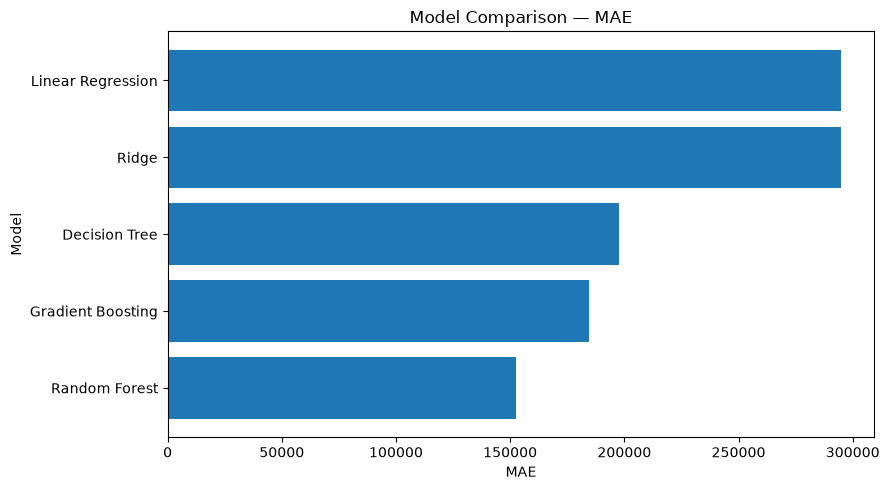

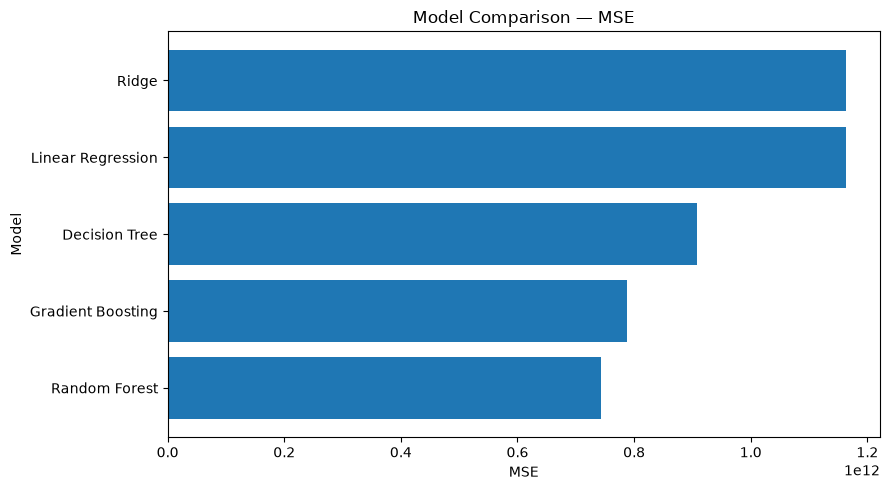

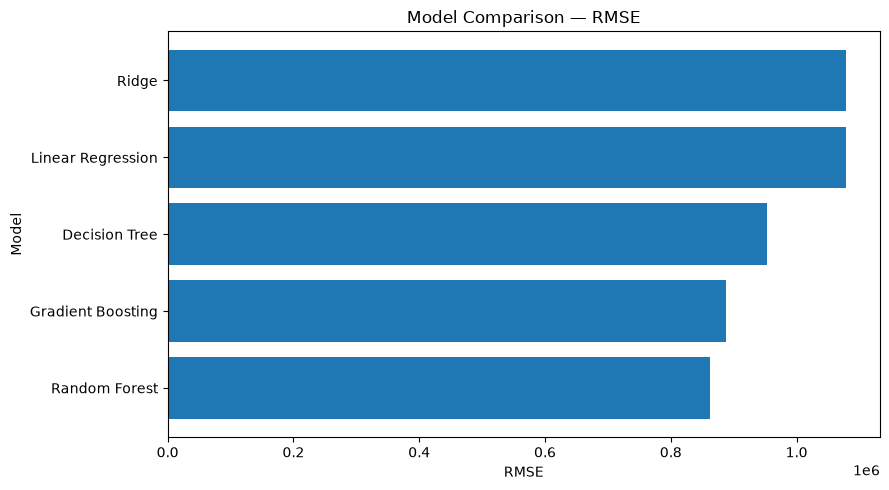

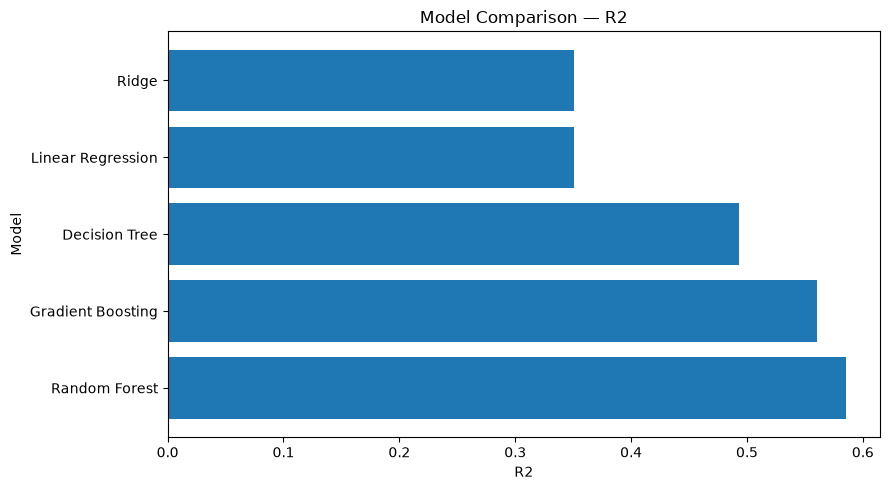

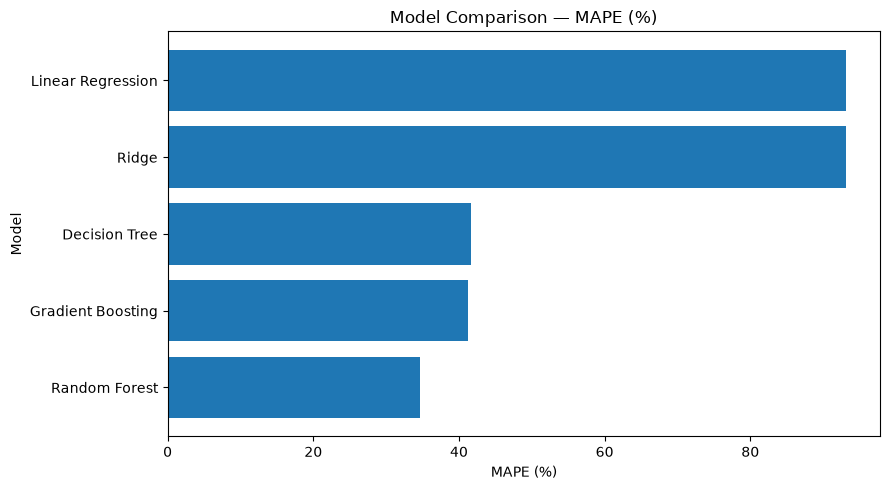

In [27]:
# ============================================================
# Compare models across five regression metrics
# ============================================================

metrics_for_plot = [
    "MAE",
    "MSE",
    "RMSE",
    "R2",
    "MAPE (%)"
]


for metric in metrics_for_plot:

    ascending = (
        metric != "R2"
    )

    plot_df = (
        comparison_df
        .sort_values(
            metric,
            ascending=ascending
        )
    )

    plt.figure(
        figsize=(9, 5)
    )

    plt.barh(
        plot_df["Model"],
        plot_df[metric]
    )

    plt.xlabel(
        metric
    )

    plt.ylabel(
        "Model"
    )

    plt.title(
        f"Model Comparison — {metric}"
    )

    plt.tight_layout()

    plt.show()

## 19. Evaluation

### Question

How accurately can the selected model predict house prices on previously unseen data?

The selected model is evaluated on the isolated test set using the same five regression metrics:

$$
MAE =
\frac{1}{N}
\sum_{i=1}^{N}
|y_i-\hat{y}_i|
$$

$$
MSE =
\frac{1}{N}
\sum_{i=1}^{N}
(y_i-\hat{y}_i)^2
$$

$$
RMSE =
\sqrt{MSE}
$$

$$
R^2 =
1-
\frac{
\sum_{i=1}^{N}
(y_i-\hat{y}_i)^2
}{
\sum_{i=1}^{N}
(y_i-\bar{y})^2
}
$$

$$
MAPE =
\frac{100}{N}
\sum_{i=1}^{N}
\left|
\frac{y_i-\hat{y}_i}{y_i}
\right|
$$

Lower MAE, MSE, RMSE, and MAPE indicate smaller prediction errors.

Higher $R^2$ indicates stronger explanatory performance.

The test set is used only after model selection so that it remains an unbiased estimate of final generalization performance.

In [28]:
# ============================================================
# 19. Validation Evaluation
# ============================================================

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    mean_absolute_percentage_error
)


# ------------------------------------------------------------
# Evaluate the five trained models on the validation set
# ------------------------------------------------------------

evaluation_results = []


validation_predictions = {}


for model_name, model in trained_models.items():

    # --------------------------------------------------------
    # Generate validation predictions
    # --------------------------------------------------------

    prediction = model.predict(
        X_val_processed
    )


    # --------------------------------------------------------
    # Store predictions for later analysis
    # --------------------------------------------------------

    validation_predictions[
        model_name
    ] = prediction


    # --------------------------------------------------------
    # Calculate evaluation metrics
    # --------------------------------------------------------

    mae = mean_absolute_error(
        y_val,
        prediction
    )


    mse = mean_squared_error(
        y_val,
        prediction
    )


    rmse = np.sqrt(
        mse
    )


    r2 = r2_score(
        y_val,
        prediction
    )


    mape = (
        mean_absolute_percentage_error(
            y_val,
            prediction
        )
        * 100
    )


    # --------------------------------------------------------
    # Store results
    # --------------------------------------------------------

    evaluation_results.append({

        "Model":
            model_name,

        "MAE":
            mae,

        "MSE":
            mse,

        "RMSE":
            rmse,

        "R2":
            r2,

        "MAPE (%)":
            mape

    })


# ------------------------------------------------------------
# Create evaluation table
# ------------------------------------------------------------

evaluation_df = (

    pd.DataFrame(
        evaluation_results
    )

    .sort_values(
        by="RMSE",
        ascending=True
    )

    .reset_index(
        drop=True
    )

)


# ------------------------------------------------------------
# Display results
# ------------------------------------------------------------

display(
    evaluation_df.round(4)
)

,Model,MAE,MSE,RMSE,R2,MAPE (%)
0,Random Forest,152731.1988,7.429454e+11,8.619428e+05,0.5855,34.6867
1,Gradient Boosting,184571.6445,7.879160e+11,8.876463e+05,0.5604,41.2625
2,Decision Tree,197778.6777,9.085018e+11,9.531536e+05,0.4932,41.6170
3,Linear Regression,294794.5481,1.163482e+12,1.078648e+06,0.3509,93.1496
4,Ridge,294747.8883,1.163507e+12,1.078660e+06,0.3509,93.1155


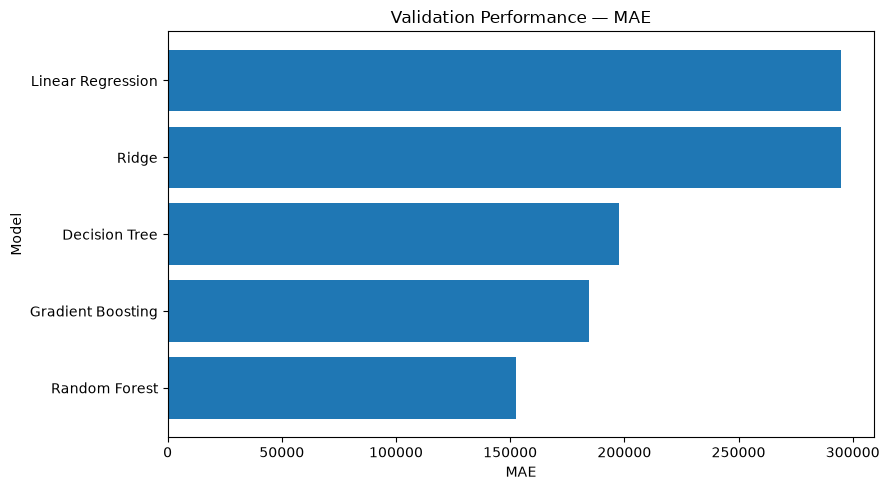

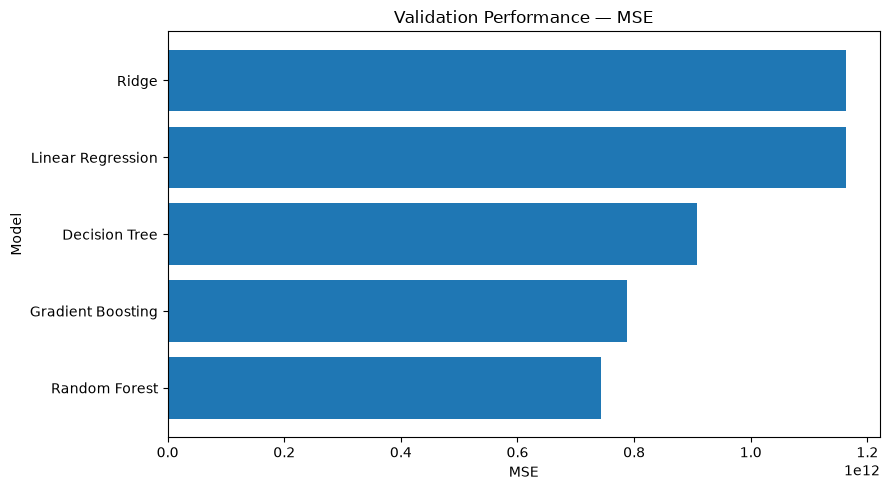

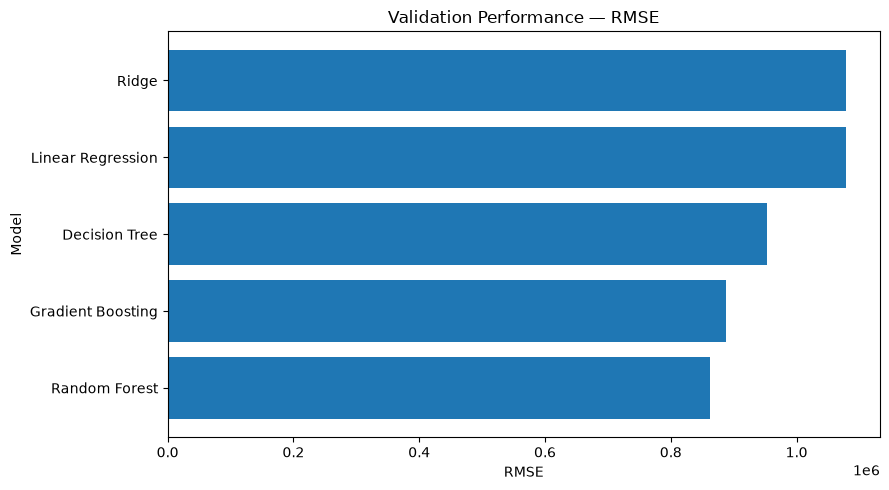

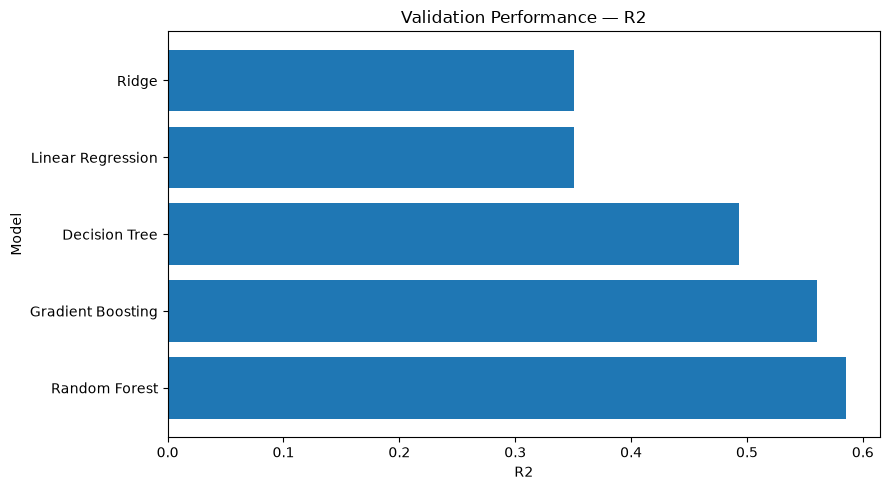

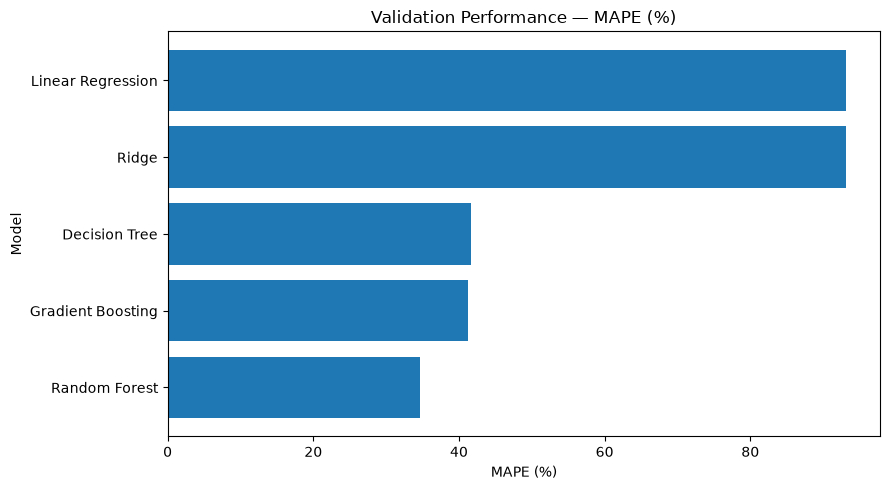

In [29]:
# ============================================================
# Validation performance comparison
# ============================================================

metrics_for_plot = [
    "MAE",
    "MSE",
    "RMSE",
    "R2",
    "MAPE (%)"
]


for metric in metrics_for_plot:

    ascending = (
        metric != "R2"
    )


    plot_df = (
        evaluation_df
        .sort_values(
            by=metric,
            ascending=ascending
        )
    )


    plt.figure(
        figsize=(9, 5)
    )


    plt.barh(
        plot_df["Model"],
        plot_df[metric]
    )


    plt.xlabel(
        metric
    )

    plt.ylabel(
        "Model"
    )

    plt.title(
        f"Validation Performance — {metric}"
    )


    plt.tight_layout()

    plt.show()

### Interpretation

The largest absolute errors identify properties for which the final model has the greatest difficulty estimating price.

These errors should not automatically be treated as data errors. They may result from unusual property characteristics, extreme prices, location-specific effects, or information that is not represented by the selected features.

This analysis therefore provides evidence about the model's limitations rather than simply reporting another performance score.

## 20. Hyperparameter Experiments

Three focused experiments are used to investigate how selected hyperparameters affect validation performance.

The experiments are intentionally limited to parameters with a clear modelling interpretation.

The validation set is used for these experiments, while the test set remains untouched.

### Experiment 1 — Ridge Regularization

#### Question

How does regularization strength affect Ridge Regression?

The parameter $\alpha$ controls the strength of regularization.

The following values are compared:

$$
\alpha \in
\{0.01,0.1,1,10,100\}
$$

The objective is to determine whether regularization improves validation performance compared with ordinary Linear Regression.

In [30]:
# ============================================================
# Experiment 1: Ridge alpha
# ============================================================

ridge_results = []


for alpha in [
    0.01,
    0.1,
    1,
    10,
    100
]:

    model = Ridge(
        alpha=alpha
    )


    start_time = (
        time.perf_counter()
    )


    model.fit(

        X_train_processed,

        y_train

    )


    training_time = (

        time.perf_counter()
        -
        start_time

    )


    prediction = (

        model
        .predict(
            X_val_processed
        )

    )


    ridge_results.append({

        "alpha":
            alpha,

        "MAE":
            mean_absolute_error(
                y_val,
                prediction
            ),

        "RMSE":
            np.sqrt(
                mean_squared_error(
                    y_val,
                    prediction
                )
            ),

        "R2":
            r2_score(
                y_val,
                prediction
            ),

        "Training Time (s)":
            round(
                training_time,
                4
            )

    })


ridge_experiment_df = (

    pd.DataFrame(
        ridge_results
    )

    .sort_values(
        "RMSE"
    )

    .reset_index(
        drop=True
    )

)


display(
    ridge_experiment_df
)

,alpha,MAE,RMSE,R2,Training Time (s)
0,0.01,294794.079248,1.078648e+06,0.350928,0.4237
1,0.10,294789.861381,1.078649e+06,0.350927,0.4355
2,1.00,294747.888309,1.078660e+06,0.350914,0.4318
3,10.00,294349.663503,1.078775e+06,0.350775,0.4563
4,100.00,291268.501383,1.080151e+06,0.349118,0.4067


### Experiment 2 — Random Forest Ensemble Size

#### Question

Does increasing the number of trees improve predictive performance enough to justify the additional computational cost?

The experiment evaluates:

$$
n_{\text{estimators}}
\in
\{50,100,200,300\}
$$

All other Random Forest parameters remain fixed.

In [31]:
# ============================================================
# Experiment 2: Random Forest number of trees
# ============================================================

rf_results = []


for n_trees in [
    50,
    100,
    200,
    300
]:

    model = RandomForestRegressor(

        n_estimators=n_trees,

        max_depth=16,

        min_samples_leaf=2,

        n_jobs=-1,

        random_state=RANDOM_SEED

    )


    start_time = (
        time.perf_counter()
    )


    model.fit(

        X_train_processed,

        y_train

    )


    training_time = (

        time.perf_counter()
        -
        start_time

    )


    prediction = (

        model
        .predict(
            X_val_processed
        )

    )


    rf_results.append({

        "n_estimators":
            n_trees,

        "MAE":
            mean_absolute_error(
                y_val,
                prediction
            ),

        "RMSE":
            np.sqrt(
                mean_squared_error(
                    y_val,
                    prediction
                )
            ),

        "R2":
            r2_score(
                y_val,
                prediction
            ),

        "Training Time (s)":
            round(
                training_time,
                4
            )

    })


rf_experiment_df = (

    pd.DataFrame(
        rf_results
    )

    .sort_values(
        "RMSE"
    )

    .reset_index(
        drop=True
    )

)


display(
    rf_experiment_df
)

,n_estimators,MAE,RMSE,R2,Training Time (s)
0,50,152361.292843,854701.806253,0.592467,124.8755
1,100,152392.155141,857399.708406,0.589890,245.0910
2,300,152382.472572,861086.773907,0.586356,734.0384
3,200,152731.198848,861942.827236,0.585533,490.6894


### Experiment 3 — Gradient Boosting Learning Rate

#### Question

How does the learning rate affect the trade-off between prediction performance and training behaviour?

The experiment evaluates:

$$
learning\_rate
\in
\{0.01,0.05,0.1,0.2\}
$$

The number of boosting stages and tree depth remain fixed.

In [32]:
# ============================================================
# Experiment 3: Gradient Boosting learning rate
# ============================================================

gb_results = []


for learning_rate in [
    0.01,
    0.05,
    0.1,
    0.2
]:

    model = GradientBoostingRegressor(

        n_estimators=200,

        learning_rate=learning_rate,

        max_depth=4,

        random_state=RANDOM_SEED

    )


    start_time = (
        time.perf_counter()
    )


    model.fit(

        X_train_processed,

        y_train

    )


    training_time = (

        time.perf_counter()
        -
        start_time

    )


    prediction = (

        model
        .predict(
            X_val_processed
        )

    )


    gb_results.append({

        "learning_rate":
            learning_rate,

        "MAE":
            mean_absolute_error(
                y_val,
                prediction
            ),

        "RMSE":
            np.sqrt(
                mean_squared_error(
                    y_val,
                    prediction
                )
            ),

        "R2":
            r2_score(
                y_val,
                prediction
            ),

        "Training Time (s)":
            round(
                training_time,
                4
            )

    })


gb_experiment_df = (

    pd.DataFrame(
        gb_results
    )

    .sort_values(
        "RMSE"
    )

    .reset_index(
        drop=True
    )

)


display(
    gb_experiment_df
)

,learning_rate,MAE,RMSE,R2,Training Time (s)
0,0.20,170394.504560,8.211224e+05,0.623860,908.0307
1,0.10,175449.553588,8.526443e+05,0.594427,741.5697
2,0.05,184571.644547,8.876463e+05,0.560445,700.0012
3,0.01,259640.091686,1.042030e+06,0.394249,713.1424


## 21. Model Selection

### Question

Which model should be selected for final deployment?

The final candidate is selected using the validation data only.

RMSE is the primary criterion because it places greater penalty on large price-estimation errors.

MAE, $R^2$, training time, model complexity, robustness, and deployment practicality are considered as supporting criteria.

The test set is not used during this decision.

In [33]:
# ============================================================
# 21. Identify best configuration from each experiment
# ============================================================

best_ridge_alpha = (
    ridge_experiment_df
    .iloc[0]["alpha"]
)


best_rf_trees = (
    rf_experiment_df
    .iloc[0]["n_estimators"]
)


best_gb_learning_rate = (
    gb_experiment_df
    .iloc[0]["learning_rate"]
)


print(
    "Best Ridge alpha:",
    best_ridge_alpha
)

print(
    "Best Random Forest n_estimators:",
    best_rf_trees
)

print(
    "Best Gradient Boosting learning rate:",
    best_gb_learning_rate
)

Best Ridge alpha: 0.01
Best Random Forest n_estimators: 50.0
Best Gradient Boosting learning rate: 0.2


In [34]:
# ============================================================
# Build tuned candidate models
# ============================================================

tuned_candidates = {

    "Linear Regression":
        LinearRegression(),

    "Ridge Tuned":
        Ridge(
            alpha=best_ridge_alpha
        ),

    "Decision Tree":
        DecisionTreeRegressor(
            max_depth=12,
            min_samples_leaf=5,
            random_state=RANDOM_SEED
        ),

    "Random Forest Tuned":
        RandomForestRegressor(

            n_estimators=int(
                best_rf_trees
            ),

            max_depth=16,

            min_samples_leaf=2,

            n_jobs=-1,

            random_state=RANDOM_SEED

        ),

    "Gradient Boosting Tuned":
        GradientBoostingRegressor(

            n_estimators=200,

            learning_rate=
                best_gb_learning_rate,

            max_depth=4,

            random_state=RANDOM_SEED

        )

}


tuned_results = []

tuned_models = {}


for model_name, model in tuned_candidates.items():

    start_time = (
        time.perf_counter()
    )


    model.fit(

        X_train_processed,

        y_train

    )


    training_time = (

        time.perf_counter()
        -
        start_time

    )


    prediction = (

        model
        .predict(
            X_val_processed
        )

    )


    tuned_results.append({

        "Model":
            model_name,

        "MAE":
            mean_absolute_error(
                y_val,
                prediction
            ),

        "RMSE":
            np.sqrt(
                mean_squared_error(
                    y_val,
                    prediction
                )
            ),

        "R2":
            r2_score(
                y_val,
                prediction
            ),

        "Training Time (s)":
            round(
                training_time,
                4
            )

    })


    tuned_models[
        model_name
    ] = model


tuned_comparison_df = (

    pd.DataFrame(
        tuned_results
    )

    .sort_values(
        "RMSE"
    )

    .reset_index(
        drop=True
    )

)


display(
    tuned_comparison_df
)

,Model,MAE,RMSE,R2,Training Time (s)
0,Gradient Boosting Tuned,170394.504560,8.211224e+05,0.623860,880.2323
1,Random Forest Tuned,152361.292843,8.547018e+05,0.592467,149.7257
2,Decision Tree,197778.677719,9.531536e+05,0.493174,10.8623
3,Linear Regression,294794.548124,1.078648e+06,0.350928,2.9963
4,Ridge Tuned,294794.079248,1.078648e+06,0.350928,0.8954


### Selection Decision

The model with the lowest validation RMSE is selected as the deployment candidate.

The final choice is based on validation performance because the test set must remain an unbiased source of final performance estimation.

The selected model will be evaluated on the test set only after this decision has been made.

## 22. Error Analysis

### Question

Where does the selected model make its largest prediction errors?

For each property, the residual is:

$$
e_i=y_i-\hat{y}_i
$$

The absolute error is:

$$
|e_i|=|y_i-\hat{y}_i|
$$

Three views are used:

1. actual price versus predicted price;
2. residual distribution;
3. largest absolute errors.

### Answer

These analyses help determine whether errors are centred around zero, whether the model systematically overestimates or underestimates prices, and whether errors become larger for expensive or unusual properties.

In [35]:
# ============================================================
# 22. Prepare validation predictions for error analysis
# ============================================================

selected_model_name = (
    tuned_comparison_df
    .iloc[0]["Model"]
)


selected_model = (
    tuned_models[
        selected_model_name
    ]
)


selected_validation_prediction = (

    selected_model
    .predict(
        X_val_processed
    )

)


print(
    "Selected model:",
    selected_model_name
)

Selected model: Gradient Boosting Tuned


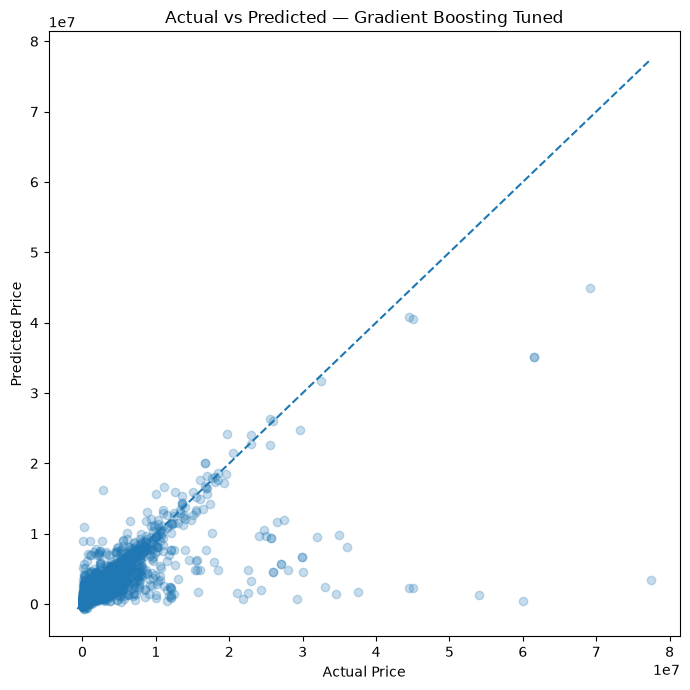

In [36]:
# ============================================================
# Actual vs predicted
# ============================================================

plt.figure(
    figsize=(7, 7)
)


plt.scatter(

    y_val,

    selected_validation_prediction,

    alpha=0.25

)


lower = min(

    y_val.min(),

    selected_validation_prediction.min()

)


upper = max(

    y_val.max(),

    selected_validation_prediction.max()

)


plt.plot(

    [lower, upper],

    [lower, upper],

    linestyle="--"

)


plt.xlabel(
    "Actual Price"
)

plt.ylabel(
    "Predicted Price"
)

plt.title(
    f"Actual vs Predicted — {selected_model_name}"
)


plt.tight_layout()

plt.show()

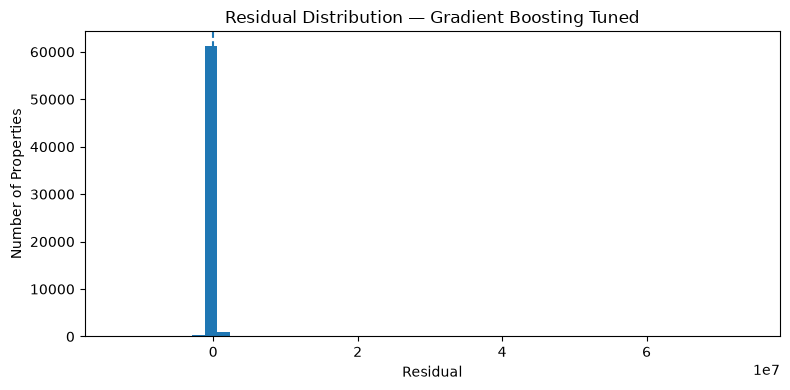

In [37]:
# ============================================================
# Residual distribution
# ============================================================

residuals = (

    y_val.to_numpy()

    -

    selected_validation_prediction

)


plt.figure(
    figsize=(8, 4)
)


plt.hist(
    residuals,
    bins=50
)


plt.axvline(
    0,
    linestyle="--"
)


plt.xlabel(
    "Residual"
)

plt.ylabel(
    "Number of Properties"
)

plt.title(
    f"Residual Distribution — {selected_model_name}"
)


plt.tight_layout()

plt.show()

In [38]:
# ============================================================
# Largest prediction errors
# ============================================================

error_analysis_df = pd.DataFrame({

    "Actual Price":
        y_val.to_numpy(),

    "Predicted Price":
        selected_validation_prediction,

    "Residual":
        residuals,

    "Absolute Error":
        np.abs(residuals)

})


display(

    error_analysis_df

    .sort_values(
        "Absolute Error",
        ascending=False
    )

    .head(10)

)

,Actual Price,Predicted Price,Residual,Absolute Error
27472,77500000,3.404110e+06,7.409589e+07,7.409589e+07
60072,60000000,3.722133e+05,5.962779e+07,5.962779e+07
40808,54000000,1.351699e+06,5.264830e+07,5.264830e+07
13809,45000000,2.287829e+06,4.271217e+07,4.271217e+07
46896,44500000,2.262281e+06,4.223772e+07,4.223772e+07
7553,37500000,1.641827e+06,3.585817e+07,3.585817e+07
52996,34500000,1.363616e+06,3.313638e+07,3.313638e+07
26749,33000000,2.364182e+06,3.063582e+07,3.063582e+07
17588,29160447,6.504100e+05,2.851004e+07,2.851004e+07
22659,36000000,8.162777e+06,2.783722e+07,2.783722e+07


### Error Interpretation

The actual-versus-predicted plot is expected to concentrate around the diagonal when predictions are accurate.

Residuals centred around zero indicate limited systematic bias.

Large residuals are particularly important because they may correspond to high-value properties, unusual property characteristics, or locations that are not sufficiently represented by the available features.

## 23. Model Persistence

### Question

How can the final machine-learning system be reused without retraining?

The final preprocessing transformer and regression model are stored together in a single pipeline.

This preserves:

- numerical imputation;
- numerical scaling;
- categorical imputation;
- one-hot encoding;
- feature ordering;
- trained model parameters.

The persisted pipeline is therefore the same computational transformation used during inference.

The test data are not used when the deployment artifact is fitted.

In [39]:
# ============================================================
# 23. Save the complete deployment pipeline
# ============================================================

import joblib


MODEL_DIR = "model"

os.makedirs(
    MODEL_DIR,
    exist_ok=True
)


final_pipeline = Pipeline([

    (
        "preprocessor",
        preprocessor
    ),

    (
        "model",
        selected_model
    )

])


# ------------------------------------------------------------
# Fit the final pipeline on training data only.
# ------------------------------------------------------------

final_pipeline.fit(

    X_train,

    y_train

)


MODEL_PATH = os.path.join(

    MODEL_DIR,

    "house_price_model_pipeline.joblib"

)


joblib.dump(

    final_pipeline,

    MODEL_PATH

)


print(
    "Pipeline saved to:"
)

print(
    MODEL_PATH
)

Pipeline saved to:
model\house_price_model_pipeline.joblib


In [40]:
# ============================================================
# Save reproducibility metadata
# ============================================================

metadata = {

    "dataset":
        "London House Price Data",

    "dataset_source":
        "https://www.kaggle.com/datasets/jakewright/house-price-data",

    "target":
        TARGET,

    "selected_model":
        selected_model_name,

    "random_seed":
        RANDOM_SEED,

    "experiment_rows":
        len(df),

    "train_rows":
        len(X_train),

    "validation_rows":
        len(X_val),

    "test_rows":
        len(X_test),

    "original_feature_dimension":
        int(
            X_engineered.shape[1]
        ),

    "final_feature_dimension":
        int(
            d_final
        ),

    "model_path":
        MODEL_PATH

}


METADATA_PATH = os.path.join(

    MODEL_DIR,

    "metadata.json"

)


with open(

    METADATA_PATH,

    "w",

    encoding="utf-8"

) as file:

    json.dump(

        metadata,

        file,

        indent=4

    )


print(
    "Metadata saved to:"
)

print(
    METADATA_PATH
)

Metadata saved to:
model\metadata.json


## 24. Inference Test

### Question

Can the persisted pipeline be loaded and used on a previously unseen property without retraining?

One observation is taken from the isolated test set.

The persisted pipeline is then reloaded independently and used to generate a prediction.

This verifies that the deployment artifact contains everything required for inference.

In [41]:
# ============================================================
# Reload the persisted pipeline
# ============================================================

loaded_pipeline = joblib.load(
    MODEL_PATH
)


print(
    "Persisted pipeline reloaded successfully."
)

Persisted pipeline reloaded successfully.


In [42]:
# ============================================================
# Inference on one unseen test property
# ============================================================

sample_input = (
    X_test
    .iloc[
        [0]
    ]
    .copy()
)


sample_actual = (
    y_test
    .iloc[0]
)


sample_prediction = (

    loaded_pipeline
    .predict(
        sample_input
    )[0]

)


sample_error = abs(

    sample_actual
    -
    sample_prediction

)


print(
    "Actual price    :",
    sample_actual
)

print(
    "Predicted price :",
    sample_prediction
)

print(
    "Absolute error  :",
    sample_error
)

Actual price    : 175000
Predicted price : 143491.54694637662
Absolute error  : 31508.45305362338


# Final Summary

The House Price application follows the complete development pipeline:

$$
\text{Raw Data}
\rightarrow
\text{Cleaning}
\rightarrow
\text{Representation}
\rightarrow
\text{Feature Engineering}
\rightarrow
\text{Preprocessing}
\rightarrow
\text{Model Training}
\rightarrow
\text{Evaluation}
\rightarrow
\text{Model Selection}
\rightarrow
\text{Persistence}
\rightarrow
\text{Inference}
$$

The original London property records are transformed from a heterogeneous tabular representation into a numerical feature matrix.

Five regression algorithms are compared, and three focused hyperparameter experiments investigate Ridge regularization, Random Forest ensemble size, and Gradient Boosting learning rate.

The final model is selected using validation performance and evaluated on the isolated test set. The selected preprocessing and model are then persisted and verified through an independent inference test.